In [18]:
import pandas as pd
df=pd.read_csv(r"D:\personal\Project\Sample - Superstore.csv\Sample - Superstore.csv",encoding="latin1")
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [19]:
print(df.shape)
print(df.columns)
df.dtypes


(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [20]:
df.isnull().sum()


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [21]:
df['Order Date']=pd.to_datetime(df['Order Date'])
print(df['Order Date'].dtype)

datetime64[ns]


In [22]:
df['Ship Date']=pd.to_datetime(df['Ship Date'])
print(df['Ship Date'].dtype)

datetime64[ns]


In [23]:
df['Order Year']=df['Order Date'].dt.year
df['Order Month']=df['Order Date'].dt.month
print(df[['Order Date','Order Month','Order Year']].head())

  Order Date  Order Month  Order Year
0 2016-11-08           11        2016
1 2016-11-08           11        2016
2 2016-06-12            6        2016
3 2015-10-11           10        2015
4 2015-10-11           10        2015


In [24]:
print("Total Sales:", round(df['Sales'].sum(), 2))
print("Total Profit:", round(df['Profit'].sum(), 2))

Total Sales: 2297200.86
Total Profit: 286397.02


In [25]:
df.groupby('Category')['Sales'].sum().round(2).sort_values(ascending=False)

Category
Technology         836154.03
Furniture          741999.80
Office Supplies    719047.03
Name: Sales, dtype: float64

In [26]:
df.groupby('Region')['Profit'].sum().round(2).sort_values(ascending=False)

Region
West       108418.45
East        91522.78
South       46749.43
Central     39706.36
Name: Profit, dtype: float64

In [27]:
df.groupby('Order Year')['Sales'].sum().round(2)

Order Year
2014    484247.50
2015    470532.51
2016    609205.60
2017    733215.26
Name: Sales, dtype: float64

In [28]:
df.groupby('Sub-Category')['Sales'].sum().round(2).sort_values(ascending=False).head()

Sub-Category
Phones     330007.05
Chairs     328449.10
Storage    223843.61
Tables     206965.53
Binders    203412.73
Name: Sales, dtype: float64

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
category_sales=df.groupby('Category')['Sales'].sum().round(2).sort_values(ascending=False)


C:\Users\dhiva\AppData\Local\Temp\ipykernel_15036\1158141172.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')


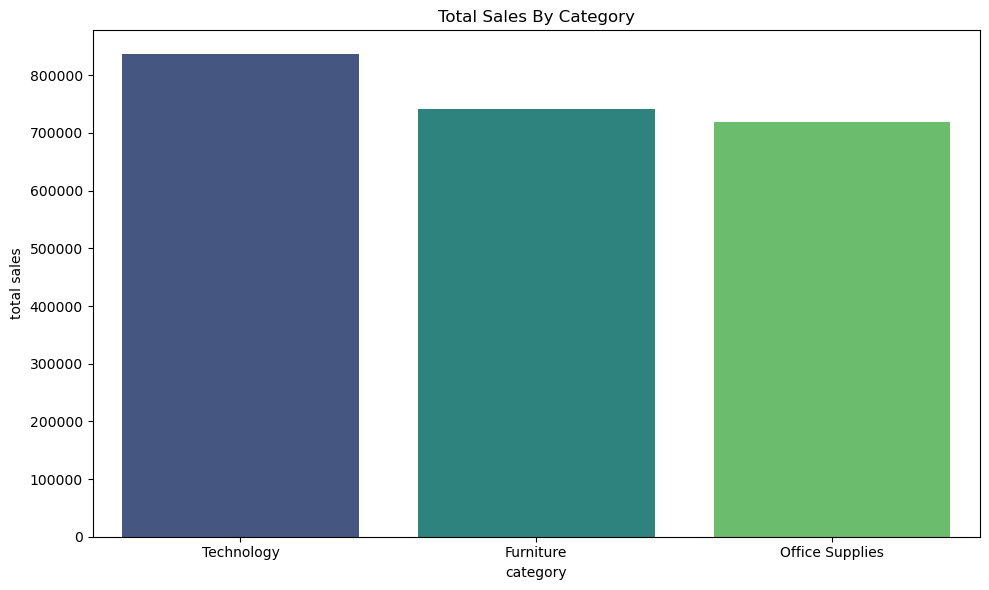

In [31]:

plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='viridis')
plt.title('Total Sales By Category')
plt.xlabel('category')
plt.ylabel('total sales')
plt.tight_layout()
plt.show()

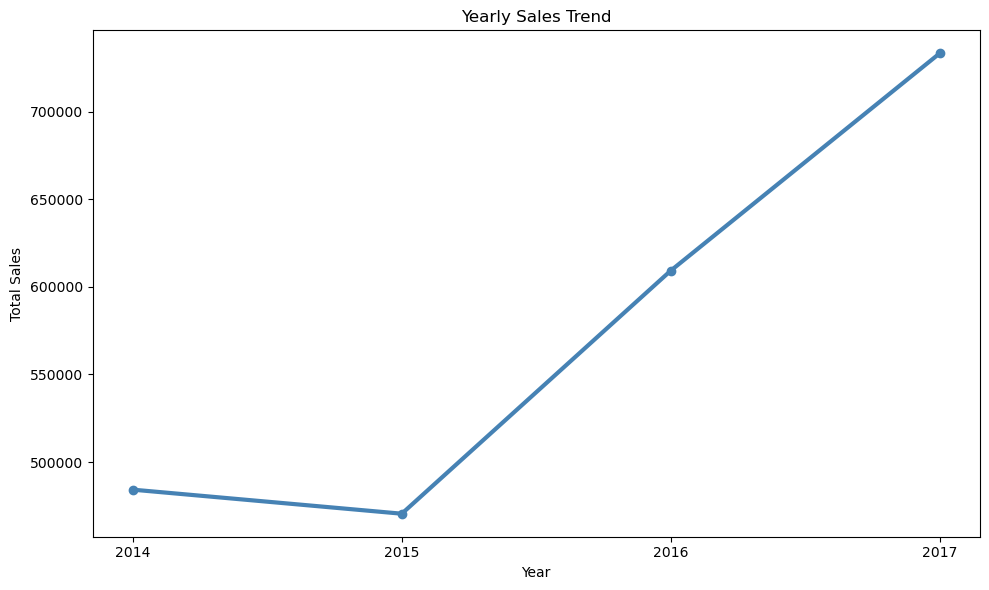

In [32]:
yearly_sales=df.groupby('Order Year')['Sales'].sum().round(2)
plt.figure(figsize=(10,6))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', color='steelblue', linewidth=3)
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks([2014,2015,2016,2017])
plt.tight_layout()
plt.show()

C:\Users\dhiva\AppData\Local\Temp\ipykernel_15036\1627265630.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_profit.values, y=region_profit.index, palette='coolwarm')


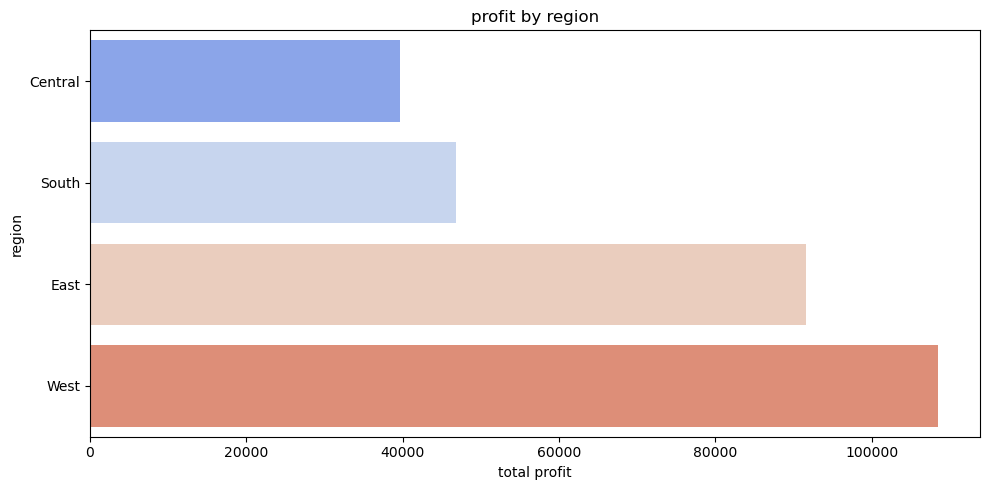

In [33]:
region_profit=df.groupby('Region')['Profit'].sum().round(2).sort_values()
plt.figure(figsize=(10,5))
sns.barplot(x=region_profit.values, y=region_profit.index, palette='coolwarm')
plt.title('profit by region')
plt.xlabel('total profit')
plt.ylabel('region')
plt.tight_layout()
plt.show()

C:\Users\dhiva\AppData\Local\Temp\ipykernel_15036\2239517014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subcategory.values, y=top_subcategory.index, palette='magma')


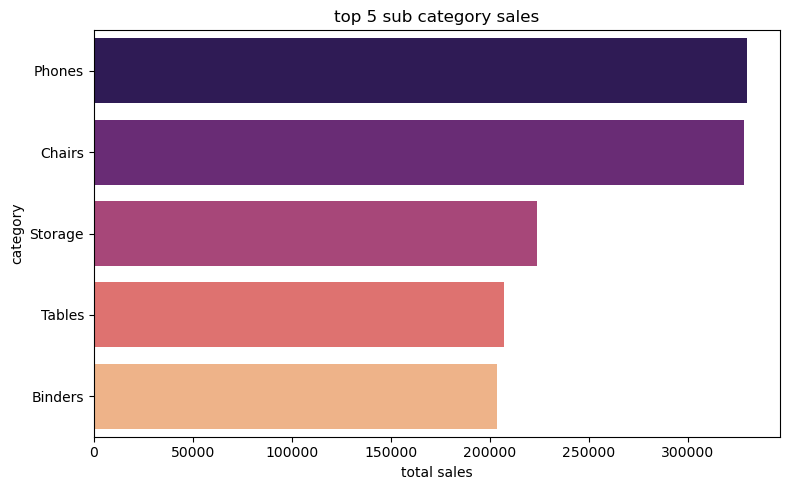

In [34]:
top_subcategory = df.groupby('Sub-Category')['Sales'].sum().round(2).sort_values(ascending=False).head()
plt.figure(figsize=(8,5))
sns.barplot(x=top_subcategory.values, y=top_subcategory.index, palette='magma')
plt.title('top 5 sub category sales')
plt.xlabel('total sales')
plt.ylabel('category')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

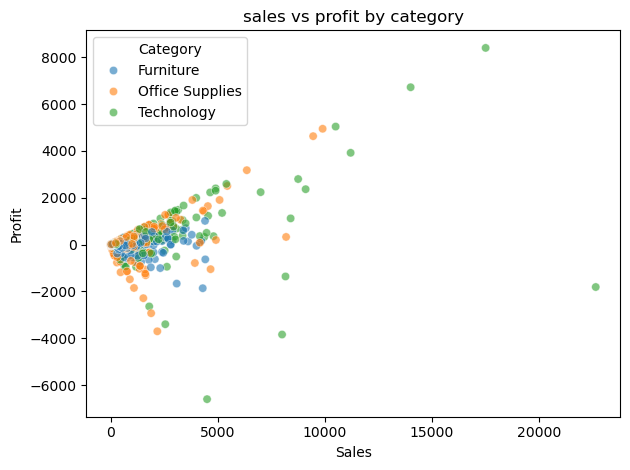

In [36]:
sns.scatterplot(x='Sales', y='Profit', data=df, hue='Category',alpha=0.6)
plt.title('sales vs profit by category')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()